In [3]:
from pathlib import Path
import importlib
import json
import os
import random
import sys
import time
import uuid

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import matplotlib.pyplot as plt
import numpy as np
import torch

def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "calvin_experiments" / "calvin_rollout_utils.py").exists():
            return path
    raise FileNotFoundError(f"Could not find guided-diffusion repo root from {start}")

REPO_ROOT = find_repo_root()
for path in [REPO_ROOT, REPO_ROOT / "robomimic", REPO_ROOT / "calvin" / "calvin_env", REPO_ROOT / "calvin_experiments"]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import robomimic.envs
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.python_utils as PyUtils
import robomimic.utils.torch_utils as TorchUtils

import calvin_experiments.calvin_rollout_utils as CalvinRolloutUtils
from calvin_experiments.label_calvin_world_model import LABEL_NAMES, label_scene_states

CalvinRolloutUtils = importlib.reload(CalvinRolloutUtils)
from calvin_experiments import calvin_rollout_utils as CRU

CONFIG_DIR = REPO_ROOT / "calvin_experiments" / "configs"
SCENE_CONFIG_PATH = CONFIG_DIR / "blocks_hidden.json"
CHECKPOINT_PATH = REPO_ROOT / "outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth"
AUTOMATON_CKPT_PATH = REPO_ROOT / "outputs/calvin/automaton_world_model/h8_sh64_ah96_lh8_hh96_lr0.0001_epochs80_2026-05-04_17-15-26"
OUTPUT_ROOT = REPO_ROOT / "outputs/calvin/guidance_diagnostics"

print("repo:", REPO_ROOT)
print("labels:", list(LABEL_NAMES))

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


repo: /home/moritz/src/guided-diffusion
labels: ['switch_on', 'button_on', 'drawer_open']


In [4]:
if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Policy checkpoint not found: {CHECKPOINT_PATH}")
if not AUTOMATON_CKPT_PATH.exists():
    raise FileNotFoundError(f"Automaton checkpoint not found: {AUTOMATON_CKPT_PATH}")

device = TorchUtils.get_torch_device(try_to_use_cuda=True)
policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=str(CHECKPOINT_PATH), device=device, verbose=False)
env = None
base_env_state = None

automaton_model, automaton_stats, automaton_meta = CRU.automaton_model_for_eval(AUTOMATON_CKPT_PATH, device)

def seed_everything(seed):
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def _to_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()
    return np.asarray(value)

def _format_onehot(values):
    return "[" + " ".join(f"{int(v):1d}" for v in values) + "]"

def _format_probs(values):
    return "[" + " ".join(f"{float(v):6.3f}" for v in values) + "]"

def current_automaton_state_and_label(env):
    state = env.get_state()
    robot = np.asarray(state["robot"], dtype=np.float32).reshape(-1)
    scene = np.asarray(state["scene"], dtype=np.float32).reshape(-1)
    automaton_state = np.concatenate([robot, scene]).astype(np.float32)
    automaton_label = label_scene_states(scene[None, :])[0].astype(np.float32)
    return automaton_state, automaton_label

def _repeat_obs_batch(obs_tensor, n):
    if n == 1:
        return obs_tensor
    return {key: value.repeat((n,) + (1,) * (value.ndim - 1)) for key, value in obs_tensor.items()}

def _unnormalize_action_sequence(action_sequence):
    action_np = _to_numpy(action_sequence).astype(np.float32)
    if policy.action_normalization_stats is None:
        return action_np
    original_shape = action_np.shape
    flat_actions = action_np.reshape(-1, original_shape[-1])
    action_keys = policy.policy.global_config.train.action_keys
    action_shapes = {key: policy.action_normalization_stats[key]["offset"].shape[1:] for key in policy.action_normalization_stats}
    action_dict = PyUtils.vector_to_action_dict(flat_actions, action_shapes=action_shapes, action_keys=action_keys)
    action_dict = ObsUtils.unnormalize_dict(action_dict, normalization_stats=policy.action_normalization_stats)
    return PyUtils.action_dict_to_vector(action_dict, action_keys=action_keys).reshape(original_shape)

def predict_future_label_probs(automaton_state, automaton_label, action_chunks):
    action_chunks = np.asarray(action_chunks, dtype=np.float32)
    if action_chunks.ndim != 3:
        raise ValueError(f"Expected action_chunks shape (N, H, A), got {action_chunks.shape}")
    n_candidates, _, action_dim = action_chunks.shape
    state_dim = len(automaton_stats["states_mean"])
    action_chunk_dim = len(automaton_stats["actions_mean"])
    if len(automaton_state) != state_dim:
        raise ValueError(f"Automaton state dim mismatch: rollout has {len(automaton_state)}, checkpoint expects {state_dim}.")
    if action_chunk_dim % action_dim != 0:
        raise ValueError(f"Automaton action chunk dim {action_chunk_dim} is not divisible by action dim {action_dim}")
    automaton_horizon = action_chunk_dim // action_dim
    if action_chunks.shape[1] < automaton_horizon:
        raise ValueError(f"Policy produced {action_chunks.shape[1]} actions, automaton expects horizon {automaton_horizon}")
    scored_chunks = action_chunks[:, :automaton_horizon, :].reshape(n_candidates, -1)
    states = np.repeat(np.asarray(automaton_state, dtype=np.float32)[None, :], n_candidates, axis=0)
    labels = np.repeat(np.asarray(automaton_label, dtype=np.float32)[None, :], n_candidates, axis=0)
    states_t = torch.as_tensor((states - automaton_stats["states_mean"]) / automaton_stats["states_std"], device=device, dtype=torch.float32)
    actions_t = torch.as_tensor((scored_chunks - automaton_stats["actions_mean"]) / automaton_stats["actions_std"], device=device, dtype=torch.float32)
    labels_t = torch.as_tensor(labels, device=device, dtype=torch.float32)
    with torch.no_grad():
        probs = torch.sigmoid(automaton_model(states_t, actions_t, labels_t)).detach().cpu().numpy()
    return probs, automaton_horizon

print("Loaded policy:", CHECKPOINT_PATH)
print("Loaded automaton:", automaton_meta["ckpt_path"])
print("Automaton config:", automaton_meta["model_config"])
print("Target index mapping:", {idx: name for idx, name in enumerate(LABEL_NAMES)})
print("Device:", device)


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['proprio']
using obs modality: rgb with keys: ['eye_in_hand', 'third_person']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.931892e+07
Loaded policy: /home/moritz/src/guided-diffusion/outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth
Loaded automaton: /home/moritz/src/guided-diffusion/outputs/calvin/automaton_world_model/h8_sh64_ah96_lh8_hh96_lr0.0001_epochs80_2026-05-04_17-15-26/best_model.pt
Automaton config: {'state_dim': 39, 'label_dim': 3, 'action_chunk_dim': 56, 'state_hidden': 64, 'label_hidden': 8, 'action_hidden': 96, 'head_hidden': 96, 'dropout': 0.15}
Target index mapping: {0: 'switch_on', 1: 'button_on', 2: 'drawer_open'}
Device: cuda:0


ven = NVIDIA Corporation
ven = NVIDIA Corporation
Running sample-and-rank rollout: target=0 (switch_on), seed=8, H=100, candidates=1
initial label: [0 0 0]

Rollout summary
behavior=drawer_open @ 66, steps=66 (behavior), final_label=[0 0 1]

Retrospective world-model predictions on the executed trajectory
   t    score      label       pred probs [switch button drawer]   label@+H  max button joint   led@+H
   0    0.165    [0 0 0]                  [ 0.165  0.155  0.615]    [0 0 0]            0.0000    0.000
   1    0.160    [0 0 0]                  [ 0.160  0.121  0.703]    [0 0 0]            0.0000    0.000
   2    0.165    [0 0 0]                  [ 0.165  0.115  0.746]    [0 0 0]            0.0000    0.000
   3    0.193    [0 0 0]                  [ 0.193  0.115  0.772]    [0 0 0]            0.0000    0.000
   4    0.233    [0 0 0]                  [ 0.233  0.116  0.747]    [0 0 0]            0.0000    0.000
   5    0.267    [0 0 0]                  [ 0.267  0.113  0.748]    [0 0 0]

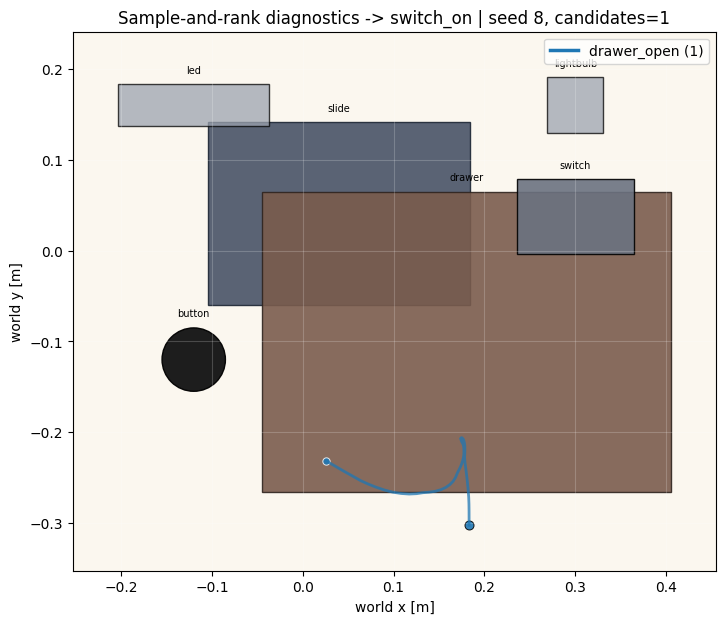

In [6]:
TARGET_LABEL_IDX = 0
N_CANDIDATES = 1
HORIZON = 100
SEED = 8
STOP_ON_BEHAVIOR = True

CRU.drop_env_quietly(globals())
env, base_env_state = CRU.load_fresh_env_from_checkpoint(
    ckpt_dict,
    seed=SEED,
    suppress_output=True,
)
fixed_scene, fixed_robot, scene_cfg = CRU.fixed_scene_robot_from_config(base_env_state, SCENE_CONFIG_PATH)
seed_everything(SEED)
obs = CRU.reset_env_to_scene_robot(env, fixed_scene, fixed_robot)
scene_snapshot = CRU.capture_scene_snapshot(env)
policy.start_episode()

start_state = env.get_state()
start_scene = np.asarray(start_state["scene"], dtype=np.float32).copy()
binaries = CRU.articulated_binaries_from_start_state(start_scene)
state0, label0 = current_automaton_state_and_label(env)

actions = []
rewards = []
dones = []
scene_states = [start_scene.copy()]
robot_states = [np.asarray(start_state["robot"], dtype=np.float32).copy()]
eef_xy = [robot_states[-1][:2].copy()]
selection_records = []
action_queue = []
detected_behavior = "none"
detected_step = -1
termination_reason = "horizon"

print(f"Running sample-and-rank rollout: target={TARGET_LABEL_IDX} ({LABEL_NAMES[TARGET_LABEL_IDX]}), seed={SEED}, H={HORIZON}, candidates={N_CANDIDATES}")
print(f"initial label: {_format_onehot(label0.astype(int))}")

for step in range(HORIZON):
    if not action_queue:
        automaton_state, automaton_label = current_automaton_state_and_label(env)
        obs_tensor = policy._prepare_observation(obs)
        obs_tensor_rank = _repeat_obs_batch(obs_tensor, N_CANDIDATES)
        with torch.no_grad():
            action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
        action_chunk = _unnormalize_action_sequence(action_chunk_n)
        candidate_probs, automaton_horizon = predict_future_label_probs(automaton_state, automaton_label, action_chunk)
        candidate_scores = candidate_probs[:, TARGET_LABEL_IDX]
        selected_idx = int(np.argmax(candidate_scores))
        selection_records.append(
            {
                "t": int(step),
                "target_label_idx": int(TARGET_LABEL_IDX),
                "target_label_name": LABEL_NAMES[TARGET_LABEL_IDX],
                "current_label": automaton_label.astype(int).tolist(),
                "selected_idx": selected_idx,
                "selected_score": float(candidate_scores[selected_idx]),
                "selected_probs": candidate_probs[selected_idx].tolist(),
                "candidate_scores": candidate_scores.tolist(),
                "candidate_probs": candidate_probs.tolist(),
            }
        )
        action_queue.extend(np.asarray(action_chunk[selected_idx, :automaton_horizon, :], dtype=np.float32))

    action_to_step = np.asarray(action_queue.pop(0), dtype=np.float32).copy()
    actions.append(action_to_step.copy())
    obs, reward, done, info = env.step(action_to_step)
    state = env.get_state()
    scene = np.asarray(state["scene"], dtype=np.float32).copy()
    robot = np.asarray(state["robot"], dtype=np.float32).copy()
    rewards.append(float(reward))
    dones.append(bool(done))
    scene_states.append(scene)
    robot_states.append(robot)
    eef_xy.append(robot[:2].copy())

    triggered = CRU.check_state_difference(start_scene, scene, robot[:3], binaries, for_display=False)
    if detected_step < 0 and triggered:
        detected_behavior = CRU.classify_behavior(start_scene, scene, robot[:3], binaries, for_display=False)
        detected_step = step + 1
        if STOP_ON_BEHAVIOR:
            termination_reason = "behavior"
            break
    if done:
        termination_reason = "env_done"
        break

statef, labelf = current_automaton_state_and_label(env)
rollout = {
    "scene_config": scene_cfg["name"],
    "seed": int(SEED),
    "behavior": detected_behavior,
    "behavior_step": int(detected_step),
    "termination_step": len(actions),
    "termination_reason": termination_reason,
    "return": float(np.sum(rewards)),
    "actions": np.asarray(actions, dtype=np.float32),
    "rewards": np.asarray(rewards, dtype=np.float32),
    "dones": np.asarray(dones, dtype=bool),
    "scene_states": np.asarray(scene_states, dtype=np.float32),
    "robot_states": np.asarray(robot_states, dtype=np.float32),
    "eef_xy": np.asarray(eef_xy, dtype=np.float32),
    "initial_label": label0.astype(int).tolist(),
    "final_label": labelf.astype(int).tolist(),
    "selection_records": selection_records,
    "scene_snapshot": scene_snapshot,
}

print("\nRollout summary")
print(f"behavior={detected_behavior} @ {detected_step}, steps={len(actions)} ({termination_reason}), final_label={_format_onehot(labelf.astype(int))}")

# Retrospective diagnostic: traverse the final executed trajectory and score the actual future action window.
trace_records = []
actions_np = rollout["actions"]
robot_np = rollout["robot_states"]
scene_np = rollout["scene_states"]
action_dim = actions_np.shape[-1] if len(actions_np) else 7
automaton_horizon = len(automaton_stats["actions_mean"]) // action_dim

print("\nRetrospective world-model predictions on the executed trajectory")
print(f"{'t':>4}  {'score':>7}  {'label':>9}  {'pred probs [switch button drawer]':>38}  {'label@+H':>9}  {'max button joint':>16}  {'led@+H':>7}")
for t in range(len(actions_np)):
    remaining = len(actions_np) - t
    if remaining >= automaton_horizon:
        action_window = actions_np[t : t + automaton_horizon]
    else:
        pad = np.repeat(actions_np[-1:][:, :], automaton_horizon - remaining, axis=0)
        action_window = np.concatenate([actions_np[t:], pad], axis=0)

    state_t = np.concatenate([robot_np[t].reshape(-1), scene_np[t].reshape(-1)]).astype(np.float32)
    label_t = label_scene_states(scene_np[t : t + 1])[0].astype(np.float32)
    probs, _ = predict_future_label_probs(state_t, label_t, action_window[None, :, :])
    probs = probs[0]
    future_idx = min(t + automaton_horizon, len(scene_np) - 1)
    future_label = label_scene_states(scene_np[future_idx : future_idx + 1])[0].astype(np.float32)
    max_button_joint = float(scene_np[t : future_idx + 1, 2].max())
    led_future = float(scene_np[future_idx, 5])
    print(
        f"{t:4d}  {probs[TARGET_LABEL_IDX]:7.3f}  {_format_onehot(label_t.astype(int)):>9}  "
        f"{_format_probs(probs):>38}  {_format_onehot(future_label.astype(int)):>9}  "
        f"{max_button_joint:16.4f}  {led_future:7.3f}"
    )
    trace_records.append(
        {
            "t": int(t),
            "score": float(probs[TARGET_LABEL_IDX]),
            "probs": probs.tolist(),
            "label": label_t.astype(int).tolist(),
            "future_idx": int(future_idx),
            "future_label": future_label.astype(int).tolist(),
            "max_button_joint_until_future": max_button_joint,
            "led_at_future": led_future,
        }
    )

run_dir = OUTPUT_ROOT / f"sample_rank_target{TARGET_LABEL_IDX}_seed{SEED}_{time.strftime('%Y%m%d_%H%M%S')}_{uuid.uuid4().hex[:8]}"
run_dir.mkdir(parents=True, exist_ok=True)
summary_path = run_dir / "diagnostic_summary.json"
plot_path = run_dir / "rollout_xy.png"
with open(summary_path, "w") as f:
    json.dump(
        {
            "target_label_idx": int(TARGET_LABEL_IDX),
            "target_label_name": LABEL_NAMES[TARGET_LABEL_IDX],
            "seed": int(SEED),
            "horizon": int(HORIZON),
            "n_candidates": int(N_CANDIDATES),
            "behavior": detected_behavior,
            "behavior_step": int(detected_step),
            "termination_step": len(actions),
            "termination_reason": termination_reason,
            "initial_label": rollout["initial_label"],
            "final_label": rollout["final_label"],
            "selection_records": selection_records,
            "trace_records": trace_records,
        },
        f,
        indent=2,
    )

print("\nsummary:", summary_path)
CRU.plot_rollout_xy(
    [rollout],
    scene_snapshot,
    f"Sample-and-rank diagnostics -> {LABEL_NAMES[TARGET_LABEL_IDX]} | seed {SEED}, candidates={N_CANDIDATES}",
    save_path=plot_path,
    display_inline=True,
)
